# Benchmark de localización y diámetro pupilar

Se usan tres recursos oficiales: LPW para centro pupilar en vídeo y los ojos izquierdos de dos participantes del dataset de Świrski/Cambridge para elipses. El participante 1 se usa para ajustar parámetros; el participante 2 queda reservado como prueba. Esto evita seleccionar y reportar parámetros sobre las mismas imágenes.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from research.validation import benchmark_lpw_cnn, benchmark_swirski, load_swirski_samples, sweep_swirski

DATA = ROOT / 'data' / 'external'
OUT = ROOT / 'docs' / 'research'
OUT.mkdir(parents=True, exist_ok=True)

In [2]:
tuning = load_swirski_samples(DATA / 'swirski' / 'p1-left')
holdout = load_swirski_samples(DATA / 'swirski' / 'p2-left')
sweep = sweep_swirski(tuning)
best = sweep.sort_values(['diameter_mae_px', 'detection_rate'], ascending=[True, False]).iloc[0]
print('Mejor configuración en participante 1:')
display(best.to_frame().T)

Mejor configuración en participante 1:


,crop_size,threshold_offset,n,detection_rate,diameter_mae_px,diameter_bias_px,diameter_spearman,center_mae_px
13,32.0,35.0,150.0,1.0,0.68179,0.110353,0.394999,1.531231


In [3]:
current_p1_results, current_p1 = benchmark_swirski(tuning, 32, 15)
current_p2_results, current_p2 = benchmark_swirski(holdout, 32, 15)
tuned_p2_results, tuned_p2 = benchmark_swirski(holdout, int(best.crop_size), int(best.threshold_offset))
comparison = pd.DataFrame([current_p1, current_p2, tuned_p2], index=['actual / ajuste P1', 'actual / prueba P2', 'ajustado / prueba P2'])
display(comparison)
assert current_p2['diameter_mae_px'] > 0.8
assert tuned_p2['diameter_mae_px'] < current_p2['diameter_mae_px']

,n,detection_rate,diameter_mae_px,diameter_bias_px,diameter_spearman,center_mae_px
actual / ajuste P1,150.0,0.946667,2.360920,-2.360920,0.453036,1.627399
actual / prueba P2,150.0,0.913333,2.743780,-2.743780,0.794722,1.441932
ajustado / prueba P2,150.0,1.000000,0.918511,-0.790341,0.808352,1.323740


## Robustez a iluminación

Se oscurece artificialmente el conjunto de prueba. No reemplaza una captura controlada, pero revela sensibilidad al recorte tonal y comprueba que un buen resultado nominal no basta.

In [4]:
brightness_rows = []
for shift in (-40, -20, 0, 20, 40):
    _, summary = benchmark_swirski(holdout, int(best.crop_size), int(best.threshold_offset), shift)
    brightness_rows.append({'brightness_shift': shift, **summary})
brightness = pd.DataFrame(brightness_rows)
display(brightness)

,brightness_shift,n,detection_rate,diameter_mae_px,diameter_bias_px,diameter_spearman,center_mae_px
0,-40,150.0,0.993333,6.991506,6.734458,0.474251,4.179426
1,-20,150.0,1.000000,2.275956,1.368648,0.380009,2.025166
2,0,150.0,1.000000,0.918511,-0.790341,0.808352,1.323740
3,20,150.0,1.000000,0.918511,-0.790341,0.808352,1.323740
4,40,150.0,1.000000,0.918511,-0.790341,0.808352,1.323740


## Generalización del CNN a posiciones pupilares no centradas (LPW)

LPW contiene vídeo de ojo con centros pupilares anotados. Es una prueba fuera de dominio —cámara ocular infrarroja, no webcam— y se reporta como *stress test*, no como estimación del rendimiento final en webcam.

In [5]:
lpw = benchmark_lpw_cnn(
    DATA / 'lpw_sample' / 'subject_01' / '9.avi',
    DATA / 'lpw_sample' / 'subject_01' / '9.txt',
    ROOT / 'src' / 'models' / 'eyestim_cnn.pth',
)
display(pd.DataFrame([lpw]))
assert lpw['mean_error_px'] >= 0.99 * lpw['constant_centre_baseline_px']

,frames,mean_error_px,median_error_px,p95_error_px,constant_centre_baseline_px,prediction_std_x,prediction_std_y
0,2000.0,14.414812,14.823491,22.703262,14.414821,0.000002,0.00009


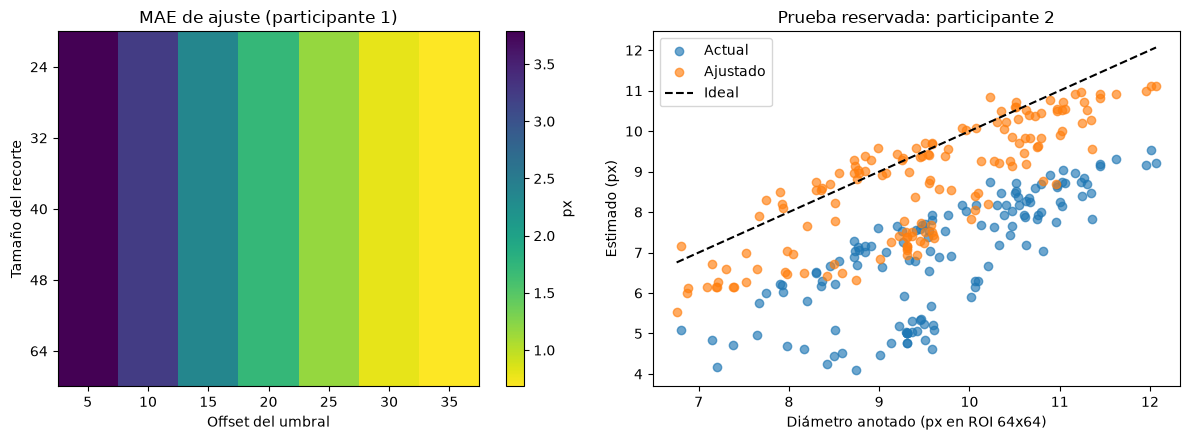

C:\Users\Eduar\AREA_PROGRAMCION\01_PROYECTOS\Eyestim\docs\research\pupilometry_benchmark.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
pivot = sweep.pivot(index='crop_size', columns='threshold_offset', values='diameter_mae_px')
image = axes[0].imshow(pivot, aspect='auto', cmap='viridis_r')
axes[0].set_xticks(range(len(pivot.columns)), pivot.columns)
axes[0].set_yticks(range(len(pivot.index)), pivot.index)
axes[0].set_xlabel('Offset del umbral'); axes[0].set_ylabel('Tamaño del recorte')
axes[0].set_title('MAE de ajuste (participante 1)'); fig.colorbar(image, ax=axes[0], label='px')
axes[1].scatter(current_p2_results.true_diameter, current_p2_results.estimated_diameter, alpha=.65, label='Actual')
axes[1].scatter(tuned_p2_results.true_diameter, tuned_p2_results.estimated_diameter, alpha=.65, label='Ajustado')
limits = [min(current_p2_results.true_diameter), max(current_p2_results.true_diameter)]
axes[1].plot(limits, limits, 'k--', label='Ideal')
axes[1].set_xlabel('Diámetro anotado (px en ROI 64x64)'); axes[1].set_ylabel('Estimado (px)')
axes[1].set_title('Prueba reservada: participante 2'); axes[1].legend()
fig.tight_layout(); figure_path = OUT / 'pupilometry_benchmark.png'; fig.savefig(figure_path, dpi=150); plt.show()
print(figure_path)

## Dictamen

El umbral actual (`+15`) falla el criterio de 0.8 px en ambos participantes. Ajustarlo a `+35` reduce el error, pero todavía obtiene 0.919 px en el participante reservado y se degrada fuertemente al oscurecer la imagen. El CNN coincide con una línea base que siempre predice el centro. Hace falta entrenar con anotaciones reales de pupila y validar por participante y dispositivo; no basta cambiar una constante.